<img src = "https://www.hh.se/images/18.4ad3d9ee1656d0f05ef643a3/1550842090193/hh-logo.svg" width = "150" align = "left">  
<br/>
<br/>
    
# Python, a Gateway to Machine Learning


## Project

The project consists of three parts:

1. a series of short exercises that help you practice with Pandas to become familiar with some of the data types and operations that they provide and also with the programming style (sometimes called pointfree: no for loops). There are more instructions in the introduction to part 1.

2. a series of short exercises that help you practice with NumPy to become familiar with some of the data types and operations that they provide and also with the programming style (sometimes called pointfree: no for loops). There are more instructions in the introduction to part 2.

3. a topic of your choice where you get to use NumPy and Pandas on real data related to weather, climate and climate change. There are more instructions in the introduction to part 3.

This project is part of the examination of the course. There are instructions on how to submit, including deadlines and advice, in the Blackboard site for the course. Please follow these instructions. There you can also see what is needed in order to pass. 




## Part 1: short exercises with Pandas

For this lab you should download two csv data files distributed with the book Learning Data Science and put them in the same folder as this Jupyter notebook. One file contains baby names:
[babynames.csv](https://halmstaduniversity.box.com/shared/static/cuij98tidhr7mwhuoni5c2y18i7rq337.csv). We also use another file that contains the arrival times of busses in Seattle (data for the stops of Seattle’s Rapid Ride lines C, D, and E at Third Avenue and Pike Street. The Washington State Transportation Center has provided times for all of the actual and scheduled stop times of these three bus lines between March 26 and May 27, 2016) [arrival_times.csv](https://halmstaduniversity.box.com/shared/static/4afc02f2bysjxrdr5idvtzg9k6m7dsn3.csv).

In [3]:
import pandas as pd

In [5]:
# Data for exercise 1:

babynames = pd.read_csv('babynames.csv')
babynames.sample(10)

,Name,Sex,Count,Year
1110704,Latrecia,F,10,1984
1897378,Ollen,M,10,1918
1858781,Georgianna,F,111,1922
1763534,Berdie,F,24,1931
577100,Leib,M,10,2004
223723,Kathaleya,F,12,2015
870141,Doneisha,F,29,1994
73527,Javarious,M,5,2019
868280,Kang,F,5,1994
273234,Lason,M,8,2013


### Exercise 1

Use Pandas operations to inspect the data and answer the following questions:

1. How many rows does the data frame have?
2. Are there any data items missing?
3. What is the earliest year included? What is the lastest year included? Are all years in between included or is there any year missing?
4. Are there equally many female names and male names all the years? If not, is there any year for which this is the case?  What are the years with more female names? And with more male names?
5. What is the number of different female names? What is the  number of different male names?
6. Are there any names that are used both as female and male names? Which ones?

In [7]:
# Code for exercise 1.1
print(f"Total number of rows is : {babynames.shape[0]}")

Total number of rows is : 2052781


#### Answer to question 1.1



In [9]:
# Code for exercise 1.2
any_data_missing = babynames.isnull().values.any()
print(f"Are there any data items missing? : {any_data_missing}")
#babynames.info()

Are there any data items missing? : False


#### Answer to question 1.2 



In [11]:
# Code for exercise 1.3 
earliest_year = babynames['Year'].min()
latest_year = babynames['Year'].max()
print(f"Earliest Year :{earliest_year}")
print(f"Latest Year : {latest_year}")

all_years = pd.DataFrame({'Year': range(earliest_year, latest_year + 1)})
missing_years = all_years[~all_years['Year'].isin(babynames['Year'])]

if not missing_years.empty:
    print("Missing years:", sorted(missing_years))
else:
    print("All years between the earliest and latest year are included.")

Earliest Year :1880
Latest Year : 2021
All years between the earliest and latest year are included.


#### Answer to question 1.3



In [13]:
# Code to help answer questions 1.4
name_counts = babynames.groupby(['Year', 'Sex'])['Name'].count().unstack()
#print(name_counts)
equal_all_years = (name_counts['F'] == name_counts['M']).all()

print("Are there equally many female names and male names all the years:", equal_all_years)

if not equal_all_years:
    print("Years with more female names:", name_counts[name_counts['F'] > name_counts['M']].index)
    print("Years with more male names:", name_counts[name_counts['M'] > name_counts['F']].index)
else:
    print("Years with equal numbers of female and male names:", name_counts[name_counts['F'] == name_counts['M']].index)

Are there equally many female names and male names all the years: False
Years with more female names: Index([1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892,
       ...
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
      dtype='int64', name='Year', length=139)
Years with more male names: Index([1880, 1881, 1882], dtype='int64', name='Year')


#### Answers to question 1.4



In [15]:
# Code to help answer question 1.5
#What is the number of different female names? What is the number of different male names?
print("Number of unique female and male names")
print(babynames.groupby(['Sex'])['Name'].nunique())

Number of unique female and male names
Sex
F    69527
M    43093
Name: Name, dtype: int64


#### Answer to question 1.5



In [21]:
# Code to help answer question 1.6
#Are there any names that are used both as female and male names? Which ones?

unisex_names = babynames.groupby('Name')['Sex'].nunique()
unisex_names = unisex_names[unisex_names > 1].index.tolist()
print("Top 10 unique names :" ,unisex_names[:10])

Top 10 unique names : ['Aaden', 'Aadi', 'Aadyn', 'Aalijah', 'Aaliyah', 'Aaliyan', 'Aamari', 'Aamir', 'Aaren', 'Aareon']


#### Answer to question 1.6



In [23]:
# Data for exercise 2:

arrival_times = pd.read_csv('arrival_times.csv')
arrival_times.sample(10)

,OPD_DATE,VEHICLE_ID,RTE,DIR,TRIP_ID,STOP_ID,STOP_NAME,SCH_STOP_TM,ACT_STOP_TM
17307,2016-05-07,6065,674,S,30908107,431,3RD AVE & PIKE ST (431),08:38:57,08:37:44
249,2016-03-26,6204,674,S,30908157,431,3RD AVE & PIKE ST (431),21:29:57,21:35:56
11606,2016-05-09,6047,675,S,30906279,431,3RD AVE & PIKE ST (431),10:57:59,10:59:47
25899,2016-05-11,6067,673,N,30905867,578,3RD AVE & PIKE ST (578),15:24:31,15:26:11
21615,2016-03-31,6062,674,N,30905728,578,3RD AVE & PIKE ST (578),15:06:29,15:10:41
15236,2016-04-17,6099,674,S,30909359,431,3RD AVE & PIKE ST (431),09:44:57,09:48:02
38136,2016-05-18,6082,674,N,30905726,578,3RD AVE & PIKE ST (578),14:27:29,14:24:25
24266,2016-05-26,6091,673,N,30905625,578,3RD AVE & PIKE ST (578),23:00:25,23:04:49
10386,2016-05-20,6206,675,S,30906376,431,3RD AVE & PIKE ST (431),08:43:59,08:41:45
11260,2016-05-12,6061,675,S,30906336,431,3RD AVE & PIKE ST (431),23:23:59,23:24:17


### Exercise 2

In the dataframe the last two columns are the scheduled time of bus arrival to the stop and the actual time of the bus arrival to the stop. 

Use Pandas operations to inspect the data and answer the following questions:

1. How many rows does the data frame have? Is there any missing data?

2. Add a column with the difference in minutes between arrival time and scheduled time. 

3. What is the arrival time where the difference between actual arrival time and scheduled arrival time is largest? 

4. Is there any arrival where the bus arrives before the scheduled time?

5. Are more buses late in the south direction or in the north direction?

In [25]:
# Code to answer exercise 2.1
#How many rows does the data frame have? Is there any missing data
print(f"Total number of rows is : {arrival_times.shape[0]}")
any_data_missing = arrival_times.isnull().values.any()
print(f"Are there any data items missing? : {any_data_missing}")

Total number of rows is : 39157
Are there any data items missing? : True


#### Answer to question 2.1



In [143]:
# Code to answer exercise 2.2
#Add a column with the difference in minutes between arrival time and scheduled time.
#print(arrival_times.dtypes)
arrival_times['SCH_STOP_TM'] = pd.to_datetime(arrival_times['SCH_STOP_TM'], format='%H:%M:%S')
arrival_times['ACT_STOP_TM'] = pd.to_datetime(arrival_times['ACT_STOP_TM'], format='%H:%M:%S')
arrival_times['DIFF_MINUTES'] = (arrival_times['ACT_STOP_TM'] - arrival_times['SCH_STOP_TM']).dt.total_seconds()/60
print(arrival_times.head())

     OPD_DATE  VEHICLE_ID  RTE DIR   TRIP_ID  STOP_ID  \
0  2016-03-26        6201  673   S  30908177      431   
1  2016-03-26        6201  673   S  30908033      431   
2  2016-03-26        6201  673   S  30908028      431   
3  2016-03-26        6201  673   S  30908019      431   
4  2016-03-26        6201  673   S  30908252      431   

                 STOP_NAME         SCH_STOP_TM         ACT_STOP_TM  \
0  3RD AVE & PIKE ST (431) 1900-01-01 01:11:57 1900-01-01 01:13:19   
1  3RD AVE & PIKE ST (431) 1900-01-01 23:19:57 1900-01-01 23:16:13   
2  3RD AVE & PIKE ST (431) 1900-01-01 21:19:57 1900-01-01 21:18:46   
3  3RD AVE & PIKE ST (431) 1900-01-01 19:04:57 1900-01-01 19:01:49   
4  3RD AVE & PIKE ST (431) 1900-01-01 16:42:57 1900-01-01 16:42:39   

   DIFF_MINUTES  
0      1.366667  
1     -3.733333  
2     -1.183333  
3     -3.133333  
4     -0.300000  


#### Answer to question 2.2



In [151]:
# Code to answer exercise 2.3
print("The largest difference between actual arrival time and scheduled arrival time" , arrival_times.loc[arrival_times['DIFF_MINUTES'].idxmax()])


The largest difference between actual arrival time and scheduled arrival time OPD_DATE                     2016-03-27
VEHICLE_ID                         6200
RTE                                 673
DIR                                   N
TRIP_ID                        30909427
STOP_ID                             578
STOP_NAME       3RD AVE & PIKE ST (578)
SCH_STOP_TM         1900-01-01 00:00:25
ACT_STOP_TM         1900-01-01 23:59:48
DIFF_MINUTES                1439.383333
Name: 20395, dtype: object


#### Answer to question 2.3



In [157]:
# Code to answer exercise 2.4
#Is there any arrival where the bus arrives before the scheduled time?
late_arrivals = arrival_times[arrival_times['ACT_STOP_TM'] < arrival_times['SCH_STOP_TM']]
print(late_arrivals)

         OPD_DATE  VEHICLE_ID  RTE DIR   TRIP_ID  STOP_ID  \
1      2016-03-26        6201  673   S  30908033      431   
2      2016-03-26        6201  673   S  30908028      431   
3      2016-03-26        6201  673   S  30908019      431   
4      2016-03-26        6201  673   S  30908252      431   
5      2016-03-26        6201  673   S  30908000      431   
...           ...         ...  ...  ..       ...      ...   
39144  2016-05-27        6213  674   N  30905960      578   
39146  2016-05-27        6213  674   N  30905967      578   
39147  2016-05-27        6213  674   N  30905751      578   
39152  2016-05-27        6215  674   N  30905957      578   
39155  2016-05-27        6215  674   N  30905740      578   

                     STOP_NAME         SCH_STOP_TM         ACT_STOP_TM  \
1      3RD AVE & PIKE ST (431) 1900-01-01 23:19:57 1900-01-01 23:16:13   
2      3RD AVE & PIKE ST (431) 1900-01-01 21:19:57 1900-01-01 21:18:46   
3      3RD AVE & PIKE ST (431) 1900-01-01 19:

#### Answer to question 2.4



In [161]:
# Code to answer exercise 2.5
#Are more buses late in the south direction or in the north direction?
late_counts_by_direction = late_arrivals['DIR'].value_counts()
print("Number of late arrivals by direction:")
print(late_counts_by_direction)
if 'S' in late_counts_by_direction and 'N' in late_counts_by_direction:
    if late_counts_by_direction['S'] > late_counts_by_direction['N']:
        print("\nMore buses are late in the South direction.")
    elif late_counts_by_direction['S'] < late_counts_by_direction['N']:
        print("\nMore buses are late in the North direction.")
    else:
        print("\nThe number of late buses is the same in both directions.")
else:
    print("\nData is missing for one or both directions.")

Number of late arrivals by direction:
DIR
S    8310
N    7815
Name: count, dtype: int64

More buses are late in the South direction.


#### Answer to question 2.5

## Part 2: short exercises with NumPy

The exercises teach you to see the differences in programming with ndarrays in NumPy and lists in Python. There are exercises to teach you about how to use NumPy for linear algebra using small examples. You will need the file [a.csv](https://halmstaduniversity.box.com/shared/static/wum7yvsmg3p9cgzwsg7ia9rycogj0u3z.csv)

In [33]:
import numpy as np

In [165]:
# Two constants defined in the library:
print(np.pi)
print(np.e)

3.141592653589793
2.718281828459045


In [169]:
# Reading the content of files
# Check the file to see how it looks like!

values = np.loadtxt('a.csv', delimiter = ",")
print(values)

[[ 1.  2.  3.  4.  5.  6.]
 [ 7.  8.  9. 10. 11. 12.]]


### Exercise 3

1. The program 
```Python
np.savetxt('random-numbers.out', np.random.rand(18), delimiter = ',')  
```
generates a file with 18 random numbers in $[0, 1)$. Use the program and then read its content into an array with three rows and six columns.

2. Define a numpy array with the sinus of 100 numbers equaly separated in the interval $[-\pi, \pi]$ 



In [175]:
# Code for exercise 3.1

np.savetxt('random-numbers.out', np.random.rand(18), delimiter = ',')
data = np.loadtxt('random-numbers.out', delimiter=',').reshape(3, 6)
print(data)

[[0.40772511 0.06925906 0.05288638 0.94823348 0.86674879 0.93197737]
 [0.1685924  0.84098101 0.00174761 0.82652369 0.61902665 0.9695983 ]
 [0.62599302 0.45390655 0.16203878 0.43916195 0.51852547 0.11982685]]


In [181]:
# Code for exercise 3.2
x = np.linspace(-np.pi, np.pi, 100)

sin_values = np.sin(x)

print(sin_values)


[-1.22464680e-16 -6.34239197e-02 -1.26592454e-01 -1.89251244e-01
 -2.51147987e-01 -3.12033446e-01 -3.71662456e-01 -4.29794912e-01
 -4.86196736e-01 -5.40640817e-01 -5.92907929e-01 -6.42787610e-01
 -6.90079011e-01 -7.34591709e-01 -7.76146464e-01 -8.14575952e-01
 -8.49725430e-01 -8.81453363e-01 -9.09631995e-01 -9.34147860e-01
 -9.54902241e-01 -9.71811568e-01 -9.84807753e-01 -9.93838464e-01
 -9.98867339e-01 -9.99874128e-01 -9.96854776e-01 -9.89821442e-01
 -9.78802446e-01 -9.63842159e-01 -9.45000819e-01 -9.22354294e-01
 -8.95993774e-01 -8.66025404e-01 -8.32569855e-01 -7.95761841e-01
 -7.55749574e-01 -7.12694171e-01 -6.66769001e-01 -6.18158986e-01
 -5.67059864e-01 -5.13677392e-01 -4.58226522e-01 -4.00930535e-01
 -3.42020143e-01 -2.81732557e-01 -2.20310533e-01 -1.58001396e-01
 -9.50560433e-02 -3.17279335e-02  3.17279335e-02  9.50560433e-02
  1.58001396e-01  2.20310533e-01  2.81732557e-01  3.42020143e-01
  4.00930535e-01  4.58226522e-01  5.13677392e-01  5.67059864e-01
  6.18158986e-01  6.66769

In [183]:
M = 5
N = 10

### Exercise 4

Use NumPy to re-implement the programs below for arrays in NumPy (ndarray) instead of lists in Python.

0. This is an example to show what we expect. You are given a Python program like
```Python
a = [1.0] * N
a
```
and you have to complete the following two cells: 
 - a code cell with the numpy version a (np_a) and 
 - a markdown cell with Observation 4.0
 
(see below, find the cells for solving Exercise 0)

1. You are given a Python program that creates  a list of N lists with M zeroes each (test it!):
```Python
m1 = [[0] * M] * N
m1
```
You have to complete the following two cells: 
 - a code cell with the numpy version (np_m1) and 
 - a markdown cell with Observation 4.1
Make sure your array contains integers.

2. You are given a Python program that creates  a list of M lists with N zeroes each (test it!):
```Python
m2 = [[0] * N] * M
m2 
```
You have to complete the following two cells: 
 - a code cell with the numpy version (np_m2) and 
 - a markdown cell with Observation 4.2
 
3. You are given a Python program that creates  a list of the first N integers (test it!):
```Python
[i for i in range(N)]
```
You have to complete the following two cells: 
 - a code cell with the numpy version 
 - a markdown cell with Observation 4.3

4. You are given a Python program that creates  a list of N lists each of size M, with random values in $[0,1)$
```Python
import random
[[random.random() for i in range(M)] for j in range(N)]
```
You have to complete the following two cells: 
 - a code cell with the numpy version 
 - a markdown cell with Observation 4.4
 
5. In Python ```+``` as an operation on lists is concatenation. Give examples of using ```+``` with NumPy arrays and explain what it calculates. Here are some examples you can try (but do try more!)
```Python
np.ones(10)    + np.ones(10)
np.arange(10)  + np.ones(10)
np.arange(10)  + 1
np.arange(10)  + np.arange(5)
```

5. Give examples of using ```*``` with NumPy arrays and explain what it calculates. Here are some examples you can try (but do try more!)
```Python
np.ones(10)    * np.ones(10)
np.arange(10)  * np.ones(10)
np.arange(10)  * 2
np.arange(10)  * np.arange(5)
```




In [197]:
# Solution to exercise 4.0
# The numpy version of a: np_a

# We expect you to use NumPy to create an array instead of a list.
# Here is how it could look like:

np_a = np.ones(N)
np_a


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

#### Observation 4.0
*We expect you to comment on the differences you observe. In this case:*


The value is not a Python list but a NumPy array: see the constructor ```array(...)``` as the value is displayed. Also, observe that the array constructor has one list as argument. 

In [223]:
# Solution to exercise 4.1
# The numpy version of m1: np_m1
#m1 = [[0] * M] * N
#m1
np_m1 = np.zeros((N,M))
np_m1

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

#### Observation 4.1
*We expect you to comment on the differences you observe.*

Here you can say that np_m1 we got an array as the result. We gave the size of the array and shape we required as an argument to get the result as mentioned in the question.Also note that we have given N as number of rows and M as number of columns.

In [226]:
# Solution to exercise 4.2
# The numpy version of m2: np_m2
# m2 = [[0] * N] * M
# m2 
np_m2 = np.zeros((M,N))
np_m2


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

#### Observation 4.2
*We expect you to comment on the differences you observe.*

Here main thing we need to observe is if we change the order of the size arguments we get a different array. In this array m2, M is the number of rows and N is the number of columns.

In [232]:
# Solution to exercise 4.3
# The numpy version
print([i for i in range(N)])

a = np.arange(N)
a

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### Observation 4.3
*We expect you to comment on the differences you observe.*

As seen above we get an array as a result instead of list when we use numpy operators. The arrange function takes the 0(default) and N as arguments to generate an array with equal parting between them giving us same output as the question.

In [239]:
# Solution to exercise 4.4
# The numpy version 
import random
print([[random.random() for i in range(M)] for j in range(N)])

random_array = np.random.rand(N, M)

print(random_array)


[[0.7467774555014912, 0.45640240247051544, 0.09513448542970915, 0.4642846009723506, 0.8636393405764233], [0.26938593937779687, 0.390876275559625, 0.7515439435248574, 0.3599473653502592, 0.7067007741119029], [0.028008109743205, 0.3164331632332553, 0.7634924033424089, 0.02567221320221247, 0.9402973623616864], [0.35779881075086173, 0.8395111635001377, 0.5664914991552809, 0.6779605021823879, 0.8431235287862855], [0.584507541829908, 0.6593664326281519, 0.8217368021789533, 0.38509834395129783, 0.26594085727989303], [0.9297417895581008, 0.7065572492871669, 0.216683831169609, 0.19538122464022256, 0.6504576477088899], [0.3079250643089524, 0.8654988203211447, 0.53068476504181, 0.773577769431902, 0.7657031599699717], [0.29712943324264374, 0.9313599102789938, 0.01102666364603977, 0.6973061739043436, 0.07362273195709446], [0.8433099575261606, 0.42102205374056867, 0.98689874015349, 0.6601391117240062, 0.27735386435317666], [0.29614287352727653, 0.5737595693643879, 0.15901227930550854, 0.770772526568

#### Observation 4.4
*We expect you to comment on the differences you observe.*

As we are using random function we will not get same answer for both codes. But for the first code it uses random module in python to generate the value in list format, whereas the second one use the random module in numpy to generate an array instead of lsit.



In [246]:
# Code for exercise 4.5

print(np.ones(10)    + np.ones(10))
print(np.arange(10)  + np.ones(10))
print(np.arange(10)  + 1)
print(np.arange(10)  + np.arange(5))

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 1  2  3  4  5  6  7  8  9 10]


ValueError: operands could not be broadcast together with shapes (10,) (5,) 

#### Observation 4.5
*We expect you to comment on what you observe.*

For broadcasting to work in addition, the size of the array needs to be same. Hence the np.arange(10)  + np.arange(5) failed due to value error as they couldnt be broadcasted.



In [248]:
# Code for exercise 4.6
print(np.ones(10)    * np.ones(10))
print(np.arange(10)  * np.ones(10))
print(np.arange(10)  * 2)
print(np.arange(10)  * np.arange(5))



[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[ 0  2  4  6  8 10 12 14 16 18]


ValueError: operands could not be broadcast together with shapes (10,) (5,) 

#### Observation 4.6
*We expect you to comment on what you observe.*

Same for * operator . * operator doesnt do matrix multiplication operation . As for matrix multiplication size is not an issue.

For matrix multiplication we use @ oprator.

Here np.ones(10)    * np.ones(10) :: It does an elemnt wise multiplication : ([1×1,1×1,...] where both has same size.

but if the size changes..np.arange(10)  * np.arange(5) then it will throw an error cause for elemnt wise multiplication to happen, the size of 2 arrays doesnt match.

### Exercise 5

In this exercise we explore operations on ndarrays that correspond to operations in linear algebra.

Very elemetary presentations of vectors and matrices can be found in the [Khan Academy](https://www.khanacademy.org/math/linear-algebra/vectors-and-spaces) and in the [Wikipedia](https://en.wikipedia.org/wiki/Linear_algebra). 

We start with vectors (in 2D). Vectors can be described by the two coordinates of the endpoint. Here is code that illustrates this geometrically.  Of course you do not need to learn about the plotting code. You can see that pointwise addition can be interpreted as vector addition and broadcasting the scalar in multiplication can be interpreted as scaling!

In [29]:
import matplotlib.pyplot  as plt

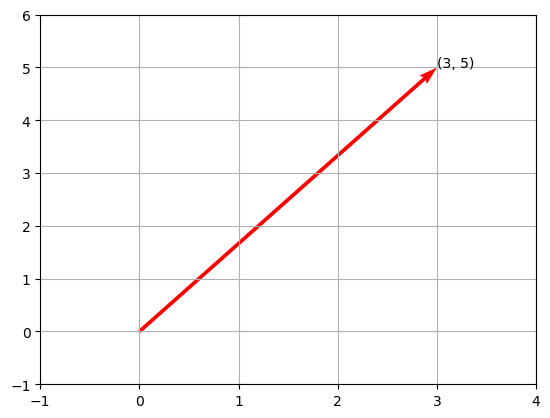

In [35]:
# The vector (3,5) (3 in x, 5 in y)

v      = np.array([3,5])

origin = np.array([0,0])

plt.quiver(origin[0], origin[1], 
           v[0], v[1], 
           color='red', 
           angles='xy', 
           scale_units='xy', 
           scale=1)

plt.annotate((v[0], v[1]), (v[0], v[1]))

plt.xlim([-1,4])
plt.ylim([-1, 6])
plt.grid()
plt.show()

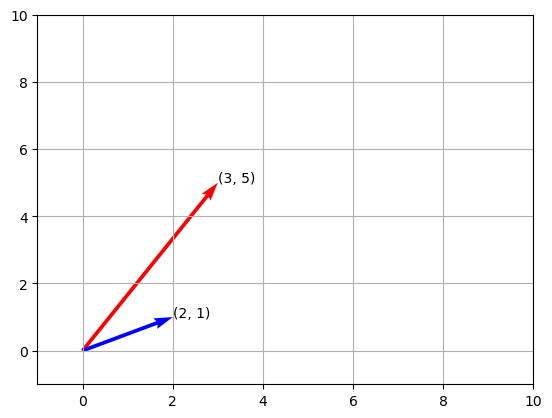

In [37]:
# Two vectors:
v1 = np.array([3,5])
v2 = np.array([2, 1])


plt.quiver(0, 0, v1[0], v1[1], 
           color       = 'red', 
           angles      = 'xy', 
           scale_units = 'xy', 
           scale       = 1)

plt.quiver(0, 0, v2[0], v2[1], 
           color       = 'blue', 
           angles      = 'xy', 
           scale_units = 'xy', 
           scale       = 1)
           

plt.annotate((v1[0], v1[1]), (v1[0], v1[1]))
plt.annotate((v2[0], v2[1]), (v2[0], v2[1]))           

plt.xlim([-1,10])
plt.ylim([-1, 10])
plt.grid()
plt.show()


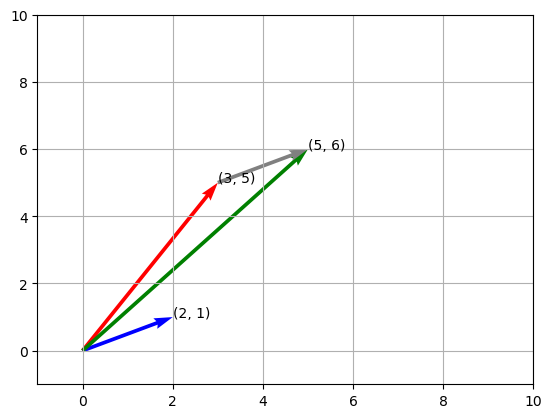

In [39]:
# Adding vectors
v1_2 = v1 + v2


plt.quiver(0, 0, v1[0], v1[1], 
           color       = 'red', 
           angles      = 'xy', 
           scale_units = 'xy', 
           scale       = 1)

plt.quiver(0, 0, v2[0], v2[1], 
           color       = 'blue', 
           angles      = 'xy', 
           scale_units = 'xy', 
           scale       = 1)


# The addition
plt.quiver(0, 0, v1_2[0], v1_2[1], 
           color       = 'green', 
           angles      = 'xy', 
           scale_units = 'xy', 
           scale       = 1)


# Help: put v2 on the endpoint of v1!
plt.quiver(v1[0], v1[1], v2[0], v2[1], 
           color       = 'gray', 
           angles      = 'xy', 
           scale_units = 'xy', 
           scale       = 1)


plt.annotate((v1[0], v1[1]), (v1[0], v1[1]))
plt.annotate((v2[0], v2[1]), (v2[0], v2[1]))           
plt.annotate((v1_2[0], v1_2[1]), (v1_2[0], v1_2[1]))  

plt.xlim([-1,10])
plt.ylim([-1, 10])
plt.grid()
plt.show()

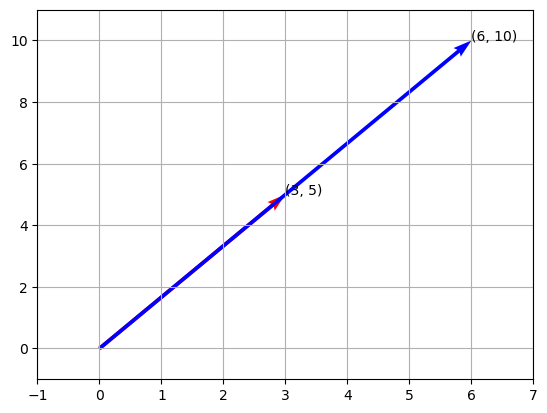

In [41]:
# Scaling vectors
vs = 2 * v

plt.quiver(0, 0, v[0], v[1], 
           color='red', 
           angles='xy', 
           scale_units='xy', 
           scale=1)


plt.quiver(0, 0, vs[0], vs[1], 
           color='blue', 
           angles='xy', 
           scale_units='xy', 
           scale=1)



plt.annotate((v[0], v[1]), (v[0], v[1]))
plt.annotate((vs[0], vs[1]), (vs[0], vs[1]))

plt.xlim([-1,7])
plt.ylim([-1,11])
plt.grid()
plt.show()

#### To the exercises
1. Write code to reverse a 2D vector (make it point in the reversed direction while keeping the sizes of the coordinates). If you can, plot it.

2. Write a function that calculates the length of a 2D vector.

3. Write a function that calculates the direction of a 2D vector as an angle from the x-axis counter clockwise.

4. Write a function that calculates the dot product of two vectors. Both vectors are ND (N dimensional): N is the length of both NumPy arrays. The dot product is a number calculated with $a \cdot b = a_0b_0 + a_1b_1 + \ldots + a_{N-1}b_{N-1}$

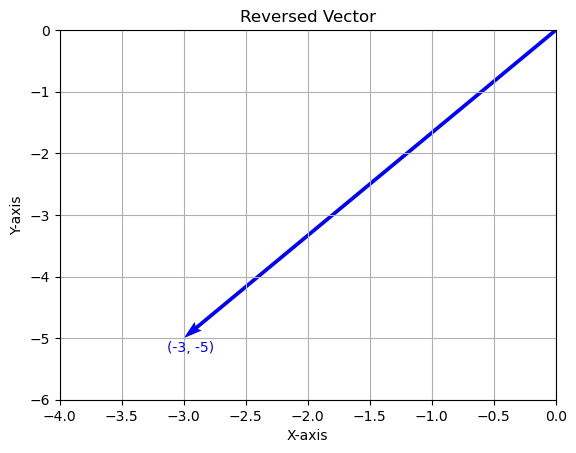

In [53]:
# Code for exercise 5.1

v = np.array([3, 5])
v_reversed = -v
origin = np.array([0, 0])

plt.figure()
plt.quiver(origin[0], origin[1], v_reversed[0], v_reversed[1], color='blue', angles='xy', scale_units='xy', scale=1)

plt.annotate(f"({v_reversed[0]}, {v_reversed[1]})", (v_reversed[0], v_reversed[1]), textcoords="offset points", xytext=(5,-10), ha='center', color='blue')

plt.xlim([-4, 0])
plt.ylim([-6, 0])
plt.grid()
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("Reversed Vector")
plt.show()



In [55]:
# Code for exercise 5.2
def vector_length(v):
    return np.sqrt(v[0]**2 + v[1]**2)

v = [3, 5]
print("Length of vector:", vector_length(v))

Length of vector: 5.830951894845301


In [57]:
# Code for exercise  5.3
def vector_direction(v):
    angle_radians = np.arctan2(v[1], v[0])
    angle_degrees = np.degrees(angle_radians)
    return angle_degrees

v = [3, 5]
print("Direction of vector (in degrees):", vector_direction(v))

Direction of vector (in degrees): 59.03624346792648


In [62]:
# Code for exercise 5.4
def dot_product(a, b):
   if len(a) != len(b):
        raise ValueError("Vectors must be the same length")
   return np.dot(a, b)

# Example usage
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("Dot product:", dot_product(a, b))


Dot product: 32


### Exercise 6

Matrices with $m$ rows and $n$ columns ($m x n$ matrices) can be represented with NumPy arrays in 2 dimensions with shape ```(m, n)```. Matrices with one row are called row vectors and matrices with one column are called column vectors. Here are some examples.

In [64]:
m = 3
n = 5
print(np.ones((m,n)))
print('-----------------------------')
print(np.random.random((m,n)))
print('-----------------------------')
print(np.random.random((1,n)))
print('-----------------------------')
print(np.random.random((m,1)))

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
-----------------------------
[[0.47691437 0.44394616 0.66952277 0.72901425 0.69236091]
 [0.68882416 0.43285103 0.74896167 0.24300212 0.23779552]
 [0.83835374 0.27047879 0.90194217 0.97242507 0.54201601]]
-----------------------------
[[0.53909309 0.12168294 0.00819592 0.07154305 0.14727699]]
-----------------------------
[[0.81964084]
 [0.25128955]
 [0.01607558]]


#### To the exercises

1. What does ```+``` do with matrices? Test at least with the following cases and explain what you observe:
```Python
np.arange(10).reshape(2,5) + 1
np.arange(10).reshape(2,5) + np.arange(10).reshape(2,5)
np.arange(10).reshape(2,5) + np.arange(5)
np.arange(10).reshape(2,5) + np.arange(2)
np.arange(10).reshape(2,5) + np.arange(10).reshape(5,2)
```

2. What does ```*``` do with matrices? Test at least with the following cases and explain what you observe:
```Python
np.arange(10).reshape(2,5) * 2
np.arange(10).reshape(2,5) * np.arange(10).reshape(2,5)
np.arange(10).reshape(2,5) * np.arange(5)
np.arange(10).reshape(2,5) * np.arange(2)
np.arange(10).reshape(2,5) * np.arange(10).reshape(5,2)
```

3. It seems that ```*``` is not the operation called [Matrix Multiplication](https://en.wikipedia.org/wiki/Matrix_multiplication) in maths! The operator ```@``` between NumPy arrays (of matching shapes for matrix multiplication) implements matrix multiplication. Test and comment on the follwing cases:
```Python
np.arange(10).reshape(2,5) @ np.arange(10).reshape(5,2)
np.arange(10).reshape(2,5) @ np.arange(5)
np.arange(10).reshape(2,5) @ np.arange(5).reshape(5,1)
np.arange(5).reshape(1,5) @ np.arange(5).reshape(5,1)
np.arange(5).reshape(5,1) @ np.arange(5).reshape(1,5)
```


4. Consider a row vector ```r``` of dimension 3 (shape 1 x 3) and a column vector ```c``` of dimension 3 (shape 3 x 1). What can you say about ```r @ c```? What mathematical operation between 3D vectors does it implement? Design some examples to test your answer.

5. For vectors as in 6.4 what can you say about ```c @ r```? What mathematical operation between 3D vectors does it implement? Design some examples to test your answer.

In [74]:
# Code for exercise 6.1
print(np.arange(10).reshape(2,5) + 1)
print("\n")
print(np.arange(10).reshape(2,5) + np.arange(10).reshape(2,5))
print("\n")
#print(np.arange(10).reshape(2,5) + np.arange(5))
print("\n")
#print(np.arange(10).reshape(2,5) + np.arange(2))
print("\n")
print(np.arange(10).reshape(2,5) + np.arange(10).reshape(5,2))


[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]


[[ 0  2  4  6  8]
 [10 12 14 16 18]]








ValueError: operands could not be broadcast together with shapes (2,5) (5,2) 

#### Answer to 6.1
np.arange(10).reshape(2,5) + 1 ::: It will add 1 to all elements in the initial array

np.arange(10).reshape(2,5) + np.arange(10).reshape(2,5) ::: It will add 2 arrays with values (0,1,2,3,4,5,6,7,8,9) to give an array of shape (2,5)

np.arange(10).reshape(2,5) + np.arange(5)
np.arange(10).reshape(2,5) + np.arange(2)
np.arange(10).reshape(2,5) + np.arange(10).reshape(5,2)) :::
While doing broadcasting addition on  two numpy array , the shape of both the arrays need to be same, if not it will throw a value error 
EG:
ValueError: operands could not be broadcast together with shapes (2,5) (5,2)

In [83]:
# Code for exercise 6.2
print(np.arange(10).reshape(2,5) * 2)
print("\n")
print(np.arange(10).reshape(2,5) * np.arange(10).reshape(2,5))
print("\n")
print(np.arange(10).reshape(2,5) * np.arange(5))
print("\n")
#print(np.arange(10).reshape(2,5) * np.arange(2))
print("\n")
print(np.arange(10).reshape(2,5) * np.arange(10).reshape(5,2))


[[ 0  2  4  6  8]
 [10 12 14 16 18]]


[[ 0  1  4  9 16]
 [25 36 49 64 81]]


[[ 0  1  4  9 16]
 [ 0  6 14 24 36]]






ValueError: operands could not be broadcast together with shapes (2,5) (5,2) 

#### Answer to 6.2
np.arange(10).reshape(2,5) * 2 :: Multiply each elemnet in the array by 2

np.arange(10).reshape(2,5) * np.arange(10).reshape(2,5) :: It does an elemnt wise multiplication : ([0×0,1×1,2×2,3×3...])

print(np.arange(10).reshape(2,5) * np.arange(5)) ::: The numpy interprets 5 as (1,5) and stretches it to match (2,5). Hence giving us an output.

np.arange(10).reshape(2,5) * np.arange(2) ::: Failed because numpy couldnt match the size and (2) couldnt be stretched like 5 to braodcast.

np.arange(10).reshape(2,5) * np.arange(10).reshape(5,2) ::: This too failed beacuse the size didnt match and it couldnt be stretched.

In [88]:
# Code for exercise 6.3
print(np.arange(10).reshape(2,5) @ np.arange(10).reshape(5,2))
print("\n")
print(np.arange(10).reshape(2,5) @ np.arange(5))
print("\n")
print(np.arange(10).reshape(2,5) @ np.arange(5).reshape(5,1))
print("\n")
print(np.arange(5).reshape(1,5) @ np.arange(5).reshape(5,1))
print("\n")
print(np.arange(5).reshape(5,1) @ np.arange(5).reshape(1,5))

[[ 60  70]
 [160 195]]


[30 80]


[[30]
 [80]]


[[30]]


[[ 0  0  0  0  0]
 [ 0  1  2  3  4]
 [ 0  2  4  6  8]
 [ 0  3  6  9 12]
 [ 0  4  8 12 16]]


#### Answer to 6.3

The @ opertator is used for matrix multiplication and in matrix multiplication shape of an array is not an issue. It can multiply any shape of arrays together.

The reulting arrays shape will be (row of array1, column of array2)

In [92]:
# Code for exercise 6.4
r = np.array([[1, 2, 3]])
c = np.array([[4], [5], [6]])  
prod = r @ c
print(prod)

[[32]]


#### Answer to 6.4
Here matrix multiplication happend between 2 matrices(1,3)(3,1) giving us an resultant array (1,1)

In [95]:
# Code for exercise 6.5
pd2 = c @ r
print(pd2)


[[ 4  8 12]
 [ 5 10 15]
 [ 6 12 18]]


#### Answer to 6.5
Here the array multiplication happen in the form (3,1)*(1,3).
when matrix multiplication happens, the reultant array will be of size (row of array1, column of array 2).
In this case the reultant will be(3,3). Hence we get the above output.

## Part 3: A topic of your choice
### Asking questions to data using Pandas and NumPy

You will work with data about weather, climate and climate change. You are free to decide what you want to calculate and investigate. You should use at least two of the following data sources:

1. Our world in data, data about CO2 (and other gases) emissions. [Direct link for download](https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.csv). The dataset is linked from https://ourworldindata.org/co2-and-greenhouse-gas-emissions.

2. NASA data on monthly mean temperatures. [Direct link for download](https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv). The dataset is linked from https://data.giss.nasa.gov/gistemp/.

3. EPA data on ocean heat. [Direct link for download](https://www.epa.gov/sites/default/files/2021-04/ocean-heat_fig-1.csv). The data is documented in https://www.epa.gov/sites/default/files/2021-04/documents/ocean-heat_td.pdf and linked from https://www.epa.gov/climate-indicators/climate-change-indicators-ocean-heat



On completion of your project your solution to Part 3 should include the following parts:

* An introduction to what it is that you want to explore. 

* A description of the data sets that you use, including the sources and what kind of data they include.

* A section for loading the data (possibly from several data sets) including  code to explore and possibly clean or reorganize the data so that you can use it for the rest of the problem.
      
* A section that asks one or more questions that can be answered by exploring, combining, transforming the data. Make sure that you use at least two of the data sources and at least five columns in total.
   
* A section with programs for the questions. The programs should work with at least two of the data sources and at least five columns in total. 

* A section with an analysis of the results of your programs to explain the answers to your questions.

In each part there can be several cells, both code and markdown. But each section has to start with a markdown cell including at least the title of the section: you will find these cells with a little explanation alredy in the notebook.



# Introduction

> 
So today I wan to explore on the impact of CO₂ emissions on temperature anomalies.</br>
In this project we will be focusing on two distinct countries: Sweden and India. Leveraging datasets provided, we aim to explore the relationship between these variables over time.

## Data sources

In this analysis we are mainly using 2 datasets. They are : </br>
1. Our World in Data: This dataset includes CO2 (and other greenhouse gases) emissions from various countries over time. Data include Year , CO₂ Emissions , Temperature Change from CO₂ and Other relevant variables.
2. NASA’s Monthly Mean Temperatures: This dataset provides global temperature anomalies from various locations, averaged monthly. It helps understand trends in temperature changes over the years. It includes Year , Temperature Anomalies, Breakdown by Month

## Programs

> Please remove this text when you are done with this section.</br>
In this section you include programs that you can run in order to try to answer your questions. 

In [12]:
#Extracting Data
import pandas as pd
import matplotlib.pyplot as plt

emissions_data = pd.read_csv('owid-co2-data.csv')  # Replace with actual file path
temperature_data = pd.read_csv('GLB.Ts+dSST.csv')  # Replace with actual file path

print("Emissions Data Columns:\n", emissions_data.head)
print("Temperature Data Columns:\n", temperature_data.head)

Emissions Data Columns:
 <bound method NDFrame.head of            country  year iso_code  population           gdp  cement_co2  \
0      Afghanistan  1850      AFG   3752993.0           NaN         NaN   
1      Afghanistan  1851      AFG   3767956.0           NaN         NaN   
2      Afghanistan  1852      AFG   3783940.0           NaN         NaN   
3      Afghanistan  1853      AFG   3800954.0           NaN         NaN   
4      Afghanistan  1854      AFG   3818038.0           NaN         NaN   
...            ...   ...      ...         ...           ...         ...   
47410     Zimbabwe  2018      ZWE  15052191.0  2.678627e+10       0.558   
47411     Zimbabwe  2019      ZWE  15354606.0  2.514642e+10       0.473   
47412     Zimbabwe  2020      ZWE  15669663.0  2.317871e+10       0.496   
47413     Zimbabwe  2021      ZWE  15993525.0  2.514009e+10       0.531   
47414     Zimbabwe  2022      ZWE  16320539.0  2.590159e+10       0.531   

       cement_co2_per_capita     co2  co2_gr

In [14]:
emissions_sweden = emissions_data[emissions_data['country'] == 'Sweden']
emissions_india = emissions_data[emissions_data['country'] == 'India']

# Filter temperature data for relevant years only
years_common = set(emissions_data['year']).intersection(temperature_data['Year'])
temperature_data = temperature_data[temperature_data['Year'].isin(years_common)]

# Merge emissions and temperature data based on the year
sweden_data = pd.merge(emissions_sweden, temperature_data, left_on='year', right_on='Year')
india_data = pd.merge(emissions_india, temperature_data, left_on='year', right_on='Year')

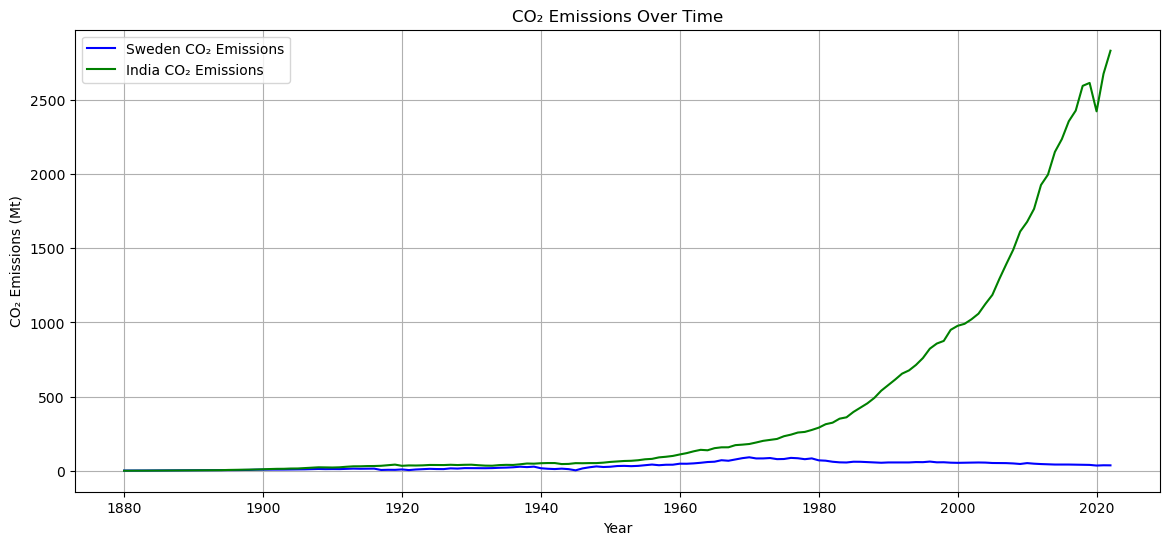

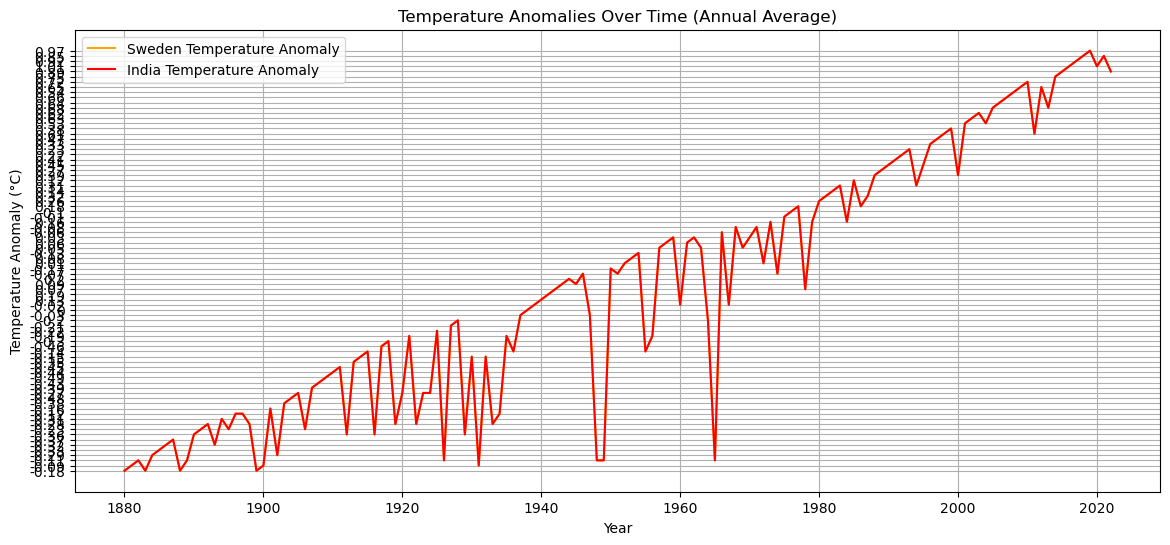

In [16]:
# Plot CO₂ Emissions Over Time for Sweden and India
plt.figure(figsize=(14, 6))
plt.plot(sweden_data['year'], sweden_data['co2'], label='Sweden CO₂ Emissions', color='blue')
plt.plot(india_data['year'], india_data['co2'], label='India CO₂ Emissions', color='green')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (Mt)')
plt.title('CO₂ Emissions Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Plot Temperature Anomalies Over Time (Annual Average: J-D column)
plt.figure(figsize=(14, 6))
plt.plot(sweden_data['year'], sweden_data['J-D'], label='Sweden Temperature Anomaly', color='orange')
plt.plot(india_data['year'], india_data['J-D'], label='India Temperature Anomaly', color='red')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Temperature Anomalies Over Time (Annual Average)')
plt.legend()
plt.grid(True)
plt.show()

## Results and analysis

To compare our data, I have chosen Sweden and India because Sweden is a developed country while India is a developing one. Analyzing the graph, we see that CO2 emissions in Sweden were very high during 1940-1980, likely during its developmental phase. In contrast, India's CO2 emissions started to rise significantly after the 1980s. After 1980, Sweden saw a drastic drop in CO2 production, due to several steps taken to control emissions and work towards sustainability.

If we look at the temperature anomaly graph, we see a steady increase over time. As the temparature anaomaly we have only has year wise value and that affects the globe , and its not country specific, which is why both Inida and Sweden has same graph plotting.

If we look at both graph ,we can see that in Sweden  while CO2 emissions impact temperature changes, other factors may also play a role. This includes global emissions and climate inertia, which means past emissions continue to influence current temperatures. Whereas in India's graph highlights a significant impact of CO2 emissions on temperature anomalies, emphasizing the need for robust emission control measures.

These trends indicate that increasing CO2 emissions is a critical factor in temperature anomalies. Still, it’s also important to consider other elements such as methane emissions, deforestation etc. which also contribute to global warming. 

Overall, while CO2 emissions are a significant driver of temperature anomalies, a holistic view considering all contributing factors is essential to fully understand and address climate change.
